# Comparing RL Agents: Q-Learning vs SARSA vs Expected SARSA

This notebook compares three Temporal-Difference (TD) learning algorithms on the DJ recommendation system:
- **Q-Learning**: Off-policy method that learns the optimal policy
- **SARSA**: On-policy method that learns the current policy
- **Expected SARSA**: On-policy method that uses expected value of next action

We'll train each agent on the same environment and compare their performance. That is why the env.py file was created, in order to recreate the same environment for each agent. 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
import random

In [6]:
from env import DJEnvironment
import pandas as pd

track_df = pd.read_csv("audio_features_df.csv")
result_df = pd.read_csv("rewards_with_motion.csv")  # Using available rewards file

# Initialize environment for later use
env = DJEnvironment(track_df, result_df, max_steps=20)

In [7]:
def state_to_key(state):
    """Convert state array to hashable key for Q-table"""
    return tuple(np.round(state, 3))


def epsilon_greedy(Q, state, n_actions, epsilon):
    state_key = state_to_key(state)
    if random.random() < epsilon:
        return random.randint(0, n_actions - 1)
    return int(np.argmax(Q[state_key]))


def moving_average(x, window=20):
    x = np.array(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode='valid')

In [8]:
def make_q_table(n_actions):
    return defaultdict(lambda: np.zeros(n_actions))

In [9]:
def train_q_learning(
    env,
    n_episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.05
):
    n_actions = len(env.tracks)
    Q = make_q_table(n_actions)
    rewards_per_episode = []

    for episode in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, n_actions, epsilon)
            result = env.step(action)
            next_state, reward, done = result[:3]

            state_key = state_to_key(state)
            next_state_key = state_to_key(next_state)
            
            best_next_action = np.argmax(Q[next_state_key])
            td_target = reward + gamma * Q[next_state_key][best_next_action] * (0 if done else 1)
            td_error = td_target - Q[state_key][action]
            Q[state_key][action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards_per_episode

In [10]:
def train_sarsa(
    env,
    n_episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.05
):
    n_actions = len(env.tracks)
    Q = make_q_table(n_actions)
    rewards_per_episode = []

    for episode in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        action = epsilon_greedy(Q, state, n_actions, epsilon)

        while not done:
            result = env.step(action)
            next_state, reward, done = result[:3]

            state_key = state_to_key(state)
            next_state_key = state_to_key(next_state)

            if not done:
                next_action = epsilon_greedy(Q, next_state, n_actions, epsilon)
                td_target = reward + gamma * Q[next_state_key][next_action]
            else:
                next_action = None
                td_target = reward

            td_error = td_target - Q[state_key][action]
            Q[state_key][action] += alpha * td_error

            state = next_state
            action = next_action
            total_reward += reward

        rewards_per_episode.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards_per_episode

In [11]:
def expected_q(Q, state, n_actions, epsilon):
    state_key = state_to_key(state)
    greedy_action = np.argmax(Q[state_key])
    probs = np.ones(n_actions) * (epsilon / n_actions)
    probs[greedy_action] += 1 - epsilon
    return np.dot(probs, Q[state_key])


def train_expected_sarsa(
    env,
    n_episodes=500,
    alpha=0.1,
    gamma=0.95,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.05
):
    n_actions = len(env.tracks)
    Q = make_q_table(n_actions)
    rewards_per_episode = []

    for episode in range(n_episodes):
        state = env.reset()
        done = False
        total_reward = 0

        while not done:
            action = epsilon_greedy(Q, state, n_actions, epsilon)
            result = env.step(action)
            next_state, reward, done = result[:3]

            state_key = state_to_key(state)

            if not done:
                td_target = reward + gamma * expected_q(Q, next_state, n_actions, epsilon)
            else:
                td_target = reward

            td_error = td_target - Q[state_key][action]
            Q[state_key][action] += alpha * td_error

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards_per_episode

In [12]:
# Training parameters
n_episodes = 500
alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

print("Training Q-Learning...")
Q_qlearning, rewards_qlearning = train_q_learning(
    env,
    n_episodes=n_episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_min=epsilon_min
)

# Reset environment
env = DJEnvironment(track_df, result_df, max_steps=20)

print("Training SARSA...")
Q_sarsa, rewards_sarsa = train_sarsa(
    env,
    n_episodes=n_episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_min=epsilon_min
)

# Reset environment
env = DJEnvironment(track_df, result_df, max_steps=20)

print("Training Expected SARSA...")
Q_expected_sarsa, rewards_expected_sarsa = train_expected_sarsa(
    env,
    n_episodes=n_episodes,
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_decay=epsilon_decay,
    epsilon_min=epsilon_min
)

print("Training complete!")

Training Q-Learning...
Training SARSA...
Training Expected SARSA...
Training complete!


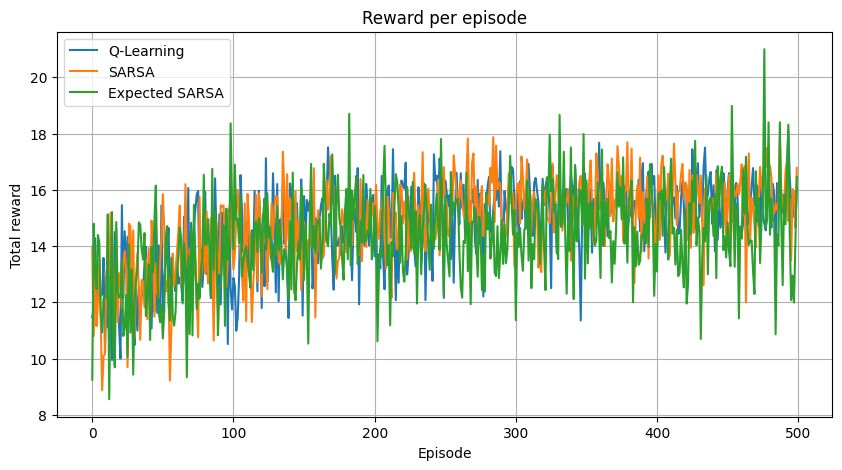

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(rewards_qlearning, label='Q-Learning')
plt.plot(rewards_sarsa, label='SARSA')
plt.plot(rewards_expected_sarsa, label='Expected SARSA')
plt.xlabel('Episode')
plt.ylabel('Total reward')
plt.title('Reward per episode')
plt.legend()
plt.grid(True)
plt.show()

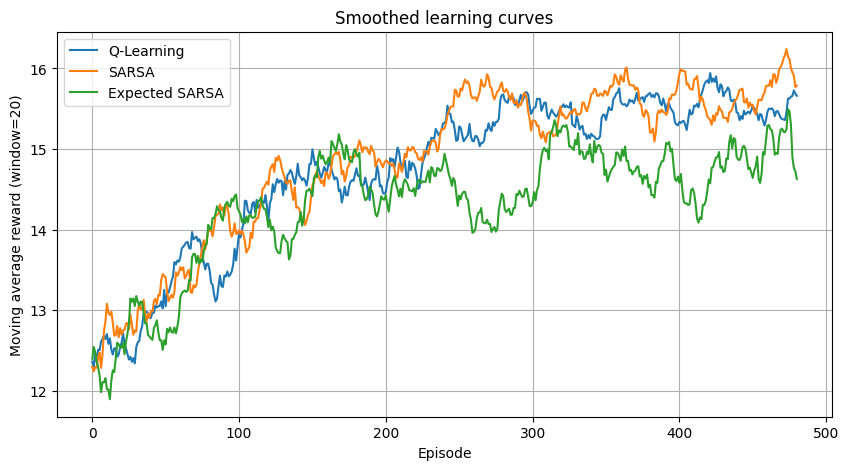

In [14]:
window = 20

ma_q = moving_average(rewards_qlearning, window)
ma_sarsa = moving_average(rewards_sarsa, window)
ma_exp_sarsa = moving_average(rewards_expected_sarsa, window)

plt.figure(figsize=(10, 5))
plt.plot(ma_q, label='Q-Learning')
plt.plot(ma_sarsa, label='SARSA')
plt.plot(ma_exp_sarsa, label='Expected SARSA')
plt.xlabel('Episode')
plt.ylabel(f'Moving average reward (window={window})')
plt.title('Smoothed learning curves')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Performance Comparison Summary
print("=" * 60)
print("PERFORMANCE COMPARISON")
print("=" * 60)

agents = {
    'Q-Learning': rewards_qlearning,
    'SARSA': rewards_sarsa,
    'Expected SARSA': rewards_expected_sarsa
}

comparison_data = []
for name, rewards in agents.items():
    mean_reward = np.mean(rewards)
    std_reward = np.std(rewards)
    max_reward = np.max(rewards)
    final_100_mean = np.mean(rewards[-100:])
    
    comparison_data.append({
        'Algorithm': name,
        'Mean Reward': mean_reward,
        'Std Dev': std_reward,
        'Max Reward': max_reward,
        'Final 100 Avg': final_100_mean
    })
    
    print(f"\n{name}:")
    print(f"  Mean Reward: {mean_reward:.4f}")
    print(f"  Std Dev: {std_reward:.4f}")
    print(f"  Max Reward: {max_reward:.4f}")
    print(f"  Final 100 Episodes Avg: {final_100_mean:.4f}")

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 60)
print("Summary Table:")
print(comparison_df.to_string(index=False))
print("=" * 60)

PERFORMANCE COMPARISON

Q-Learning:
  Mean Reward: 14.7155
  Std Dev: 1.5354
  Max Reward: 18.1161
  Final 100 Episodes Avg: 15.5449

SARSA:
  Mean Reward: 14.8231
  Std Dev: 1.5346
  Max Reward: 17.8714
  Final 100 Episodes Avg: 15.7140

Expected SARSA:
  Mean Reward: 14.2779
  Std Dev: 1.6722
  Max Reward: 20.9990
  Final 100 Episodes Avg: 14.7976

Summary Table:
     Algorithm  Mean Reward  Std Dev  Max Reward  Final 100 Avg
    Q-Learning    14.715459 1.535387   18.116081      15.544938
         SARSA    14.823139 1.534597   17.871442      15.713969
Expected SARSA    14.277888 1.672246   20.998978      14.797585


/var/folders/l2/sjl2dtm50w5bz7xnx5kmvmyc0000gn/T/ipykernel_47576/3691727649.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(reward_data, labels=['Q-Learning', 'SARSA', 'Expected SARSA'])


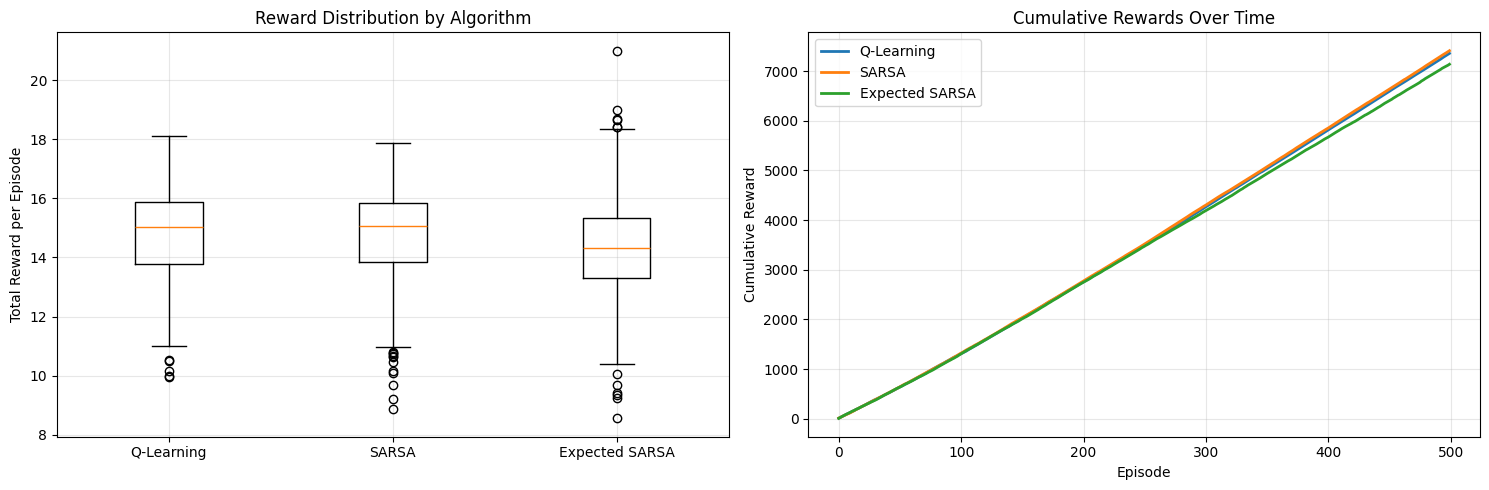

In [16]:
# Box plot comparison of reward distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
reward_data = [rewards_qlearning, rewards_sarsa, rewards_expected_sarsa]
axes[0].boxplot(reward_data, labels=['Q-Learning', 'SARSA', 'Expected SARSA'])
axes[0].set_ylabel('Total Reward per Episode')
axes[0].set_title('Reward Distribution by Algorithm')
axes[0].grid(True, alpha=0.3)

# Cumulative comparison
cumsum_q = np.cumsum(rewards_qlearning)
cumsum_s = np.cumsum(rewards_sarsa)
cumsum_es = np.cumsum(rewards_expected_sarsa)

axes[1].plot(cumsum_q, label='Q-Learning', linewidth=2)
axes[1].plot(cumsum_s, label='SARSA', linewidth=2)
axes[1].plot(cumsum_es, label='Expected SARSA', linewidth=2)
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Cumulative Reward')
axes[1].set_title('Cumulative Rewards Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Algorithm Comparison Analysis

### Key Differences:

**Q-Learning (Off-Policy):**
- Learns the optimal policy regardless of actual actions taken
- Updates based on the maximum Q-value of the next state
- Can be more aggressive in exploration
- May perform erratically during training but converges to optimal policy

**SARSA (On-Policy):**
- Learns the policy being followed during training
- Updates based on the actual next action taken
- More conservative, reflects actual policy
- Smoother learning curves but may not find optimal policy if policy is too exploratory

**Expected SARSA (On-Policy):**
- Intermediate between SARSA and Q-Learning
- Uses expected value of next state under current policy
- More stable than SARSA while staying on-policy
- Better bias-variance tradeoff than pure SARSA

### Interpretation:
- Algorithms that converge faster to higher rewards are better suited for this environment
- Lower variance indicates more stable learning
- Consider the final performance (last 100 episodes) as the most relevant metric for convergence